#### Feature selection

In [97]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [98]:
df = pd.read_csv('./Algerian_forest_fires_dataset_cleaned.csv')
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [99]:
print(df.columns)
# drop the date month and day columns
df.drop(['year','month','day'],axis=1,inplace=True)
df.head()

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [100]:
df['Classes'].value_counts()
# here i will do encoding of the classes column to make it binary
df['Classes'] = np.where(df['Classes'].str.contains('not fire'),0,1)

In [101]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [102]:
# Independent and dependent features
X = df.drop('FWI',axis=1)
y = df['FWI']

In [103]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [104]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [105]:
# Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)


In [106]:
# Feature selection based on correlation
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

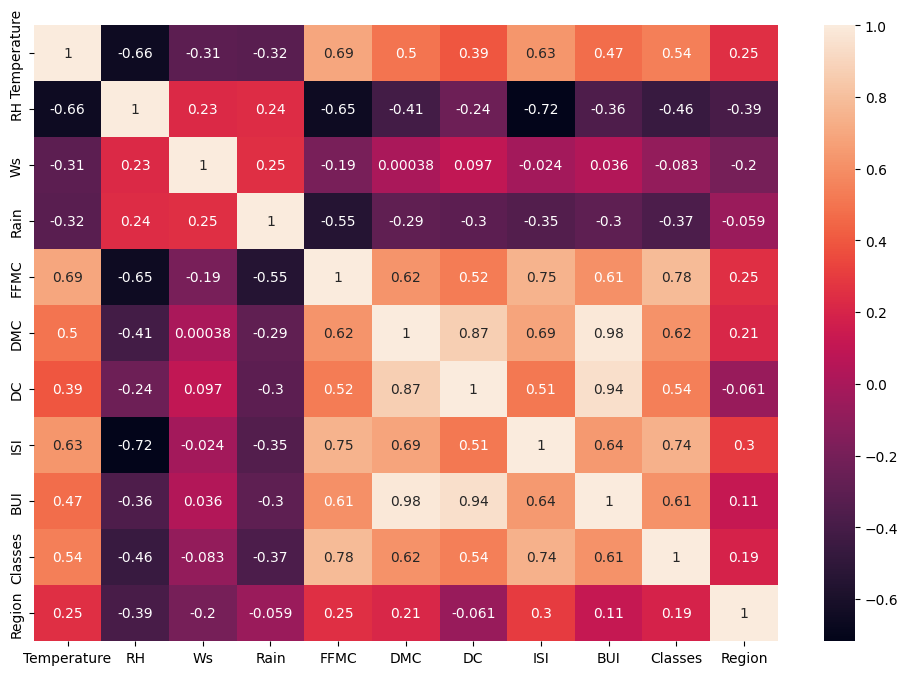

In [107]:
# check for multicollinearity
plt.figure(figsize=(12,8))
corr=X_train.corr()
sns.heatmap(corr,annot=True)

In [108]:
def correlation(dataset, threshold):
    col_corr = set() # Set of all the names of deleted columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i] # getting the name of column
                col_corr.add(colname)
    return col_corr

In [109]:
# threshold must be set by the domain expert of that dataset.
corr_features = correlation(X_train,0.85)

In [110]:
# drop these features from the training and testing dataset
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
print(X_train.shape)
X_test.shape

(182, 9)


(61, 9)

In [111]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(182, 9)
(61, 9)


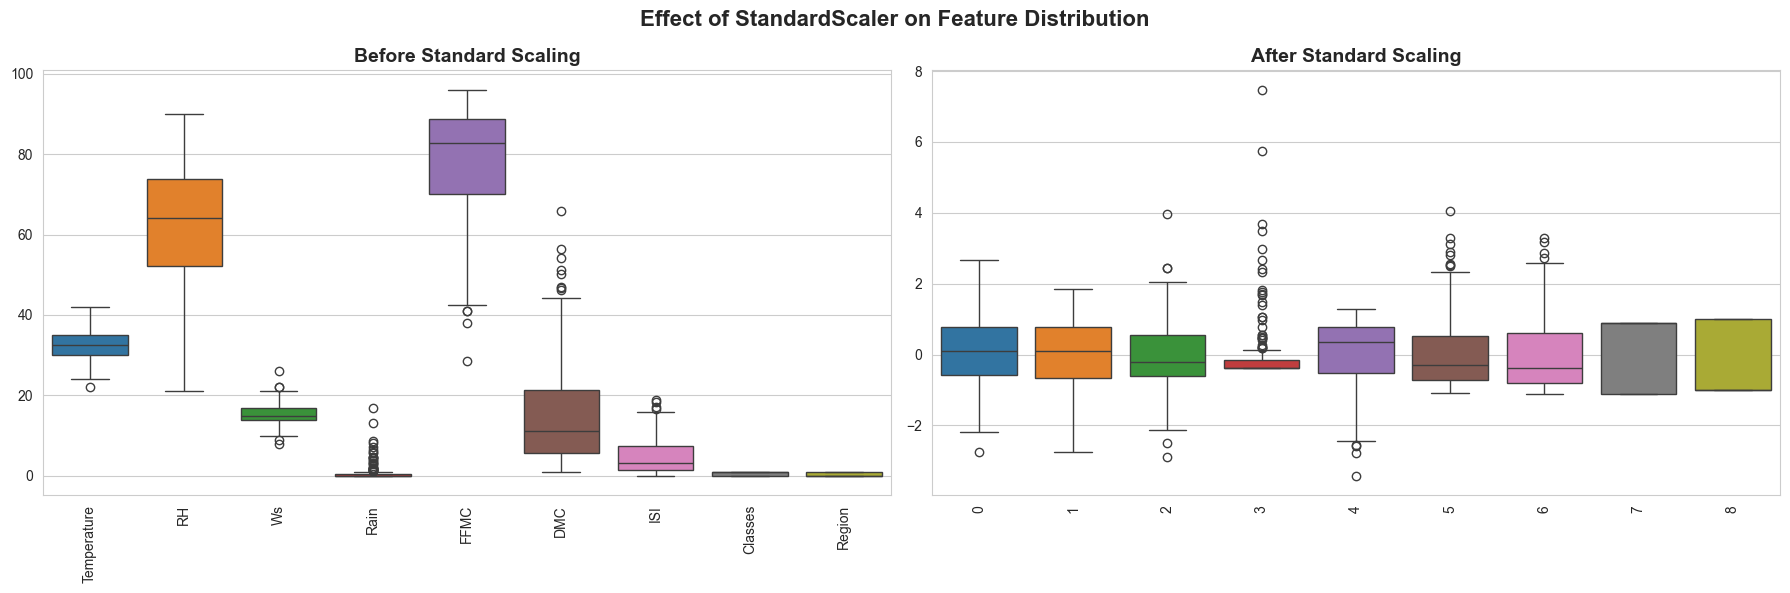

In [115]:

# Set style
sns.set_style("whitegrid")

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Before scaling
sns.boxplot(data=X_train, ax=axes[0])
axes[0].set_title("Before Standard Scaling", fontsize=14, weight='bold')
axes[0].tick_params(axis='x', rotation=90)

# After scaling
sns.boxplot(data=X_train_scaled, ax=axes[1])
axes[1].set_title("After Standard Scaling", fontsize=14, weight='bold')
axes[1].tick_params(axis='x', rotation=90)

# Main title
plt.suptitle("Effect of StandardScaler on Feature Distribution", fontsize=16, weight='bold')

# Adjust layout
plt.tight_layout()

plt.show()

#### APPLY LINEAR REGRESSION MODEL

Mean Absolute Error: 0.5468236465249978
R^2 Score: 0.9847657384266951


Text(0.5, 0, 'Actual Values')

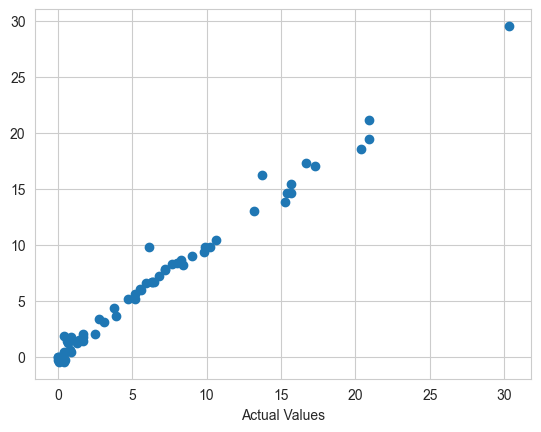

In [117]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
model = LinearRegression()
lin_reg = model.fit(X_train_scaled,y_train)
lin_reg.fit(X_train_scaled,y_train)
y_pred = lin_reg.predict(X_test_scaled)

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")

Mean Absolute Error: 0.7084773819658263
R^2 Score: 0.9783246631008717


Text(0.5, 1.0, 'Lasso Regression Results')

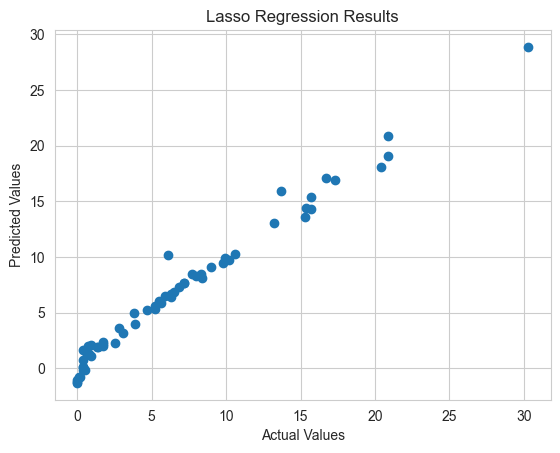

In [118]:
# Apply the Lasso regression
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled,y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_lasso))
print("R^2 Score:", r2_score(y_test, y_pred_lasso))
plt.scatter(y_test, y_pred_lasso)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Lasso Regression Results")

In [121]:
# apply lassoCV to find the best alpha value
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(cv=5)
lasso_cv.fit(X_train_scaled,y_train)
print("Best alpha value:", lasso_cv.alpha_)


Best alpha value: 0.05725391318234408


Mean Absolute Error: 0.5642305340105715
R^2 Score: 0.9842993364555512


Text(0.5, 1.0, 'Ridge Regression Results')

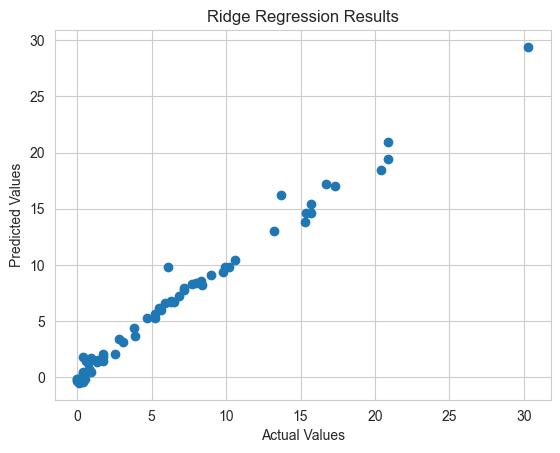

In [119]:
# Apply ridge regression model
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled,y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_ridge))
print("R^2 Score:", r2_score(y_test, y_pred_ridge))
plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression Results")


Mean Absolute Error: 0.8291276215817329
R^2 Score: 0.9745920377156688


Text(0.5, 1.0, 'Elastic Net Regression Results')

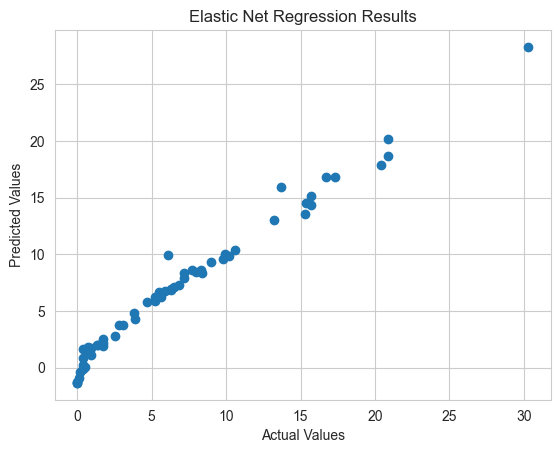

In [ ]:
# apply elastic net regression model
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X_train_scaled,y_train)
y_pred_elastic = elastic_net.predict(X_test_scaled)

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_elastic))
print("R^2 Score:", r2_score(y_test, y_pred_elastic))
plt.scatter(y_test, y_pred_elastic)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Elastic Net Regression Results")